# 🧠 Système 1 : construire un modèle de décision « JEV-like » from scratch

**Notebook pédagogique — support de webinaire**

On construit, pièce par pièce, un modèle qui reçoit un **état**, une **question** et une **liste de choix de taille variable**, et qui renvoie **en une seule passe avant** une distribution de probabilités calibrée sur ces choix. Pas de génération, pas de boucle autorégressive, pas de KV-cache : c'est un « Système 1 » rapide, destiné à servir de module de décision dans des architectures plus larges (robotique, agents ARC-AGI-3, décisions de trading rapides…).

| Partie | Contenu |
|---|---|
| 0 | Corrections et précisions importantes |
| 1 | L'idée : décision = scorer des choix en une passe |
| 2 | Setup et configuration |
| 3 | Anatomie de Qwen3-0.6B (et pourquoi pas Qwen3.5) |
| 4 | Format d'entrée : question → état → choix → fin forcée |
| 5 | `position_ids` partagés : l'invariance à l'ordre |
| 6 | Le masque d'attention 4D : les choix ne se voient jamais |
| 7 | Pooling : un vecteur par choix + un vecteur réponse |
| 8 | Tests sans entraînement (dimensions, invariance) |
| 9 | Données : schéma, générateurs procéduraux, augmentation |
| 10 | Têtes de décision : dot, bilinéaire, self-attention + bilinéaire |
| 11 | Sonde par couche, troncature 20/28, LoRA |
| 12 | Entraînement |
| 13 | Validation : précision, NLL, Brier, ECE, température, invariance, latence |
| 14 | Calibration et RL : ce qu'on sait, ce qu'on propose |
| 15 | Sauvegarde, inférence, intégration (IERM, ARC-AGI-3, trading) |
| A | Annexe : passer au code de production avec Claude Code |

**Deux modes d'exécution**

- `tiny_debug=True` (auto si pas de GPU) : un mini-Qwen3 **aléatoire** (même code, mêmes classes HF, 6 couches de largeur 128). Tout le notebook tourne sur CPU en quelques minutes : parfait pour montrer les tenseurs, masques et tests en direct pendant le webinaire. Les métriques n'ont évidemment pas de sens.
- `tiny_debug=False` : le vrai `Qwen/Qwen3-0.6B` sur GPU (A100/L4/4090…).

## 0. ⚠️ Corrections et précisions (version 0.1)

Quelques points de mes notes. Ce sont des points vérifiables, pas des opinions.

| Note | Ce qui est exact |
|---|---|
| « Qwen 0.6B est comme le 0.8B : 1 transformer pour 3 linéaires (Gated DeltaNet / Mamba2) » | **Non.** `Qwen3-0.6B` est un **transformer dense pur** : 28 couches, toutes en attention softmax complète (GQA 16 têtes Q / 8 têtes KV, QK-Norm, RoPE). Le layout hybride est celui de **Qwen3.5** : le 0.8B suit `6 × (3 × (Gated DeltaNet → FFN) → 1 × (Gated Attention → FFN))`, soit 24 couches dont 6 d'attention. Gated DeltaNet n'est pas Mamba2 : c'est une attention linéaire à « règle delta » avec gating (cousine de Mamba2, mais une autre famille). |
| Conséquence pour un futur module sur Qwen3.5-4B | **L'astuce masque 4D + `position_ids` partagés ne fonctionne pas sur les couches Gated DeltaNet** : elles sont récurrentes (un état qui se met à jour token après token), sans RoPE ni masque. Les choix concaténés « fuiraient » les uns dans les autres et l'invariance à l'ordre disparaîtrait. Pour ce module, rester sur un backbone **full-attention** (Qwen3 0.6B / 1.7B / 4B). Une alternative existe pour l'hybride (voir §15). |
| « Comme en RAG, on garde le dernier hidden state comme représentant de la séquence » | **Vrai pour un décodeur causal** : le dernier token est le seul qui a vu toute sa séquence. En RAG c'est **selon l'embedder** : CLS ou mean-pooling pour les encodeurs type BERT, last-token / EOS pour les embedders dérivés de LLM (Qwen3-Embedding, E5-Mistral). |
| « La réponse commence à `q_end+2` » | Ce n'est correct que si chaque choix fait 1 token. Avec des choix de longueur variable, la fin forcée doit commencer **après le plus long choix** : `P + L_max` (P = longueur du préfixe). Sinon la réponse aurait une position *antérieure* à certains tokens de choix qu'elle regarde. |
| « Max 255 choix, tête de sortie de taille 255 » | La limite est une **commodité d'implémentation** (padding), pas une nécessité. Avec un score par paire (`réponse · W · choix`), le nombre de choix est libre et la tête reste **équivariante**. Une `Linear(d, 255)` sur le vecteur réponse (1ʳᵉ version du code de la vidéo) **casserait** l'invariance : l'index de sortie serait lié à la position du choix. Le code final de la vidéo (einsum `bd,bcd->bc`) corrige cela. |
| Ajouter des tokens spéciaux `[CHOICE]`, `[ANSWER]`… | Piège : avec LoRA, la matrice d'embeddings est gelée, donc des tokens **nouveaux** restent aléatoires. On utilise ici des **marqueurs texte** (`Question:`, `- `, `The answer is:`) que le modèle connaît déjà. La segmentation est portée par nos index, pas par des tokens. |
| Mélanger les choix comme augmentation | Inutile si l'invariance est exacte (c'est tout l'intérêt). On garde par contre un **test** d'invariance automatique. |
| « Garder 20 couches sur 28 » | Intuition plausible et cohérente avec les travaux de sondage (les couches intermédiaires portent souvent de meilleures représentations que les dernières, spécialisées dans la prédiction du token suivant). **À mesurer** : §11 fournit une sonde par couche. |
| Méthode d'entraînement de TypeSafe AI / Jev (« RL for calibrated decisions ») | Non publiée à ma connaissance ; je ne peux pas la vérifier. On entraîne en entropie croisée (règle de score propre → calibration en espérance), on mesure la calibration, on la corrige (température) et on propose une piste RL (§14). |

## 1. L'idée : une décision = scorer des choix en une passe

Quatre façons de faire décider un LLM parmi K choix :

| Approche | Passes | Invariant à l'ordre ? | Les choix sont comparés ? | Remarque |
|---|---|---|---|---|
| Génération libre (« réponds A, B ou C ») | 1 + décodage | ❌ biais de position connu | implicitement | lent, parsing fragile, probas peu calibrées |
| Scoring LM : log-prob de chaque choix | K | ✅ si une passe par choix | ❌ | coûteux, biais de longueur |
| Cross-encoder (état + 1 choix → score) | K | ✅ | ❌ | pas de comparaison entre options |
| **Ici : une passe, choix isolés par masque, tête comparative** | **1** | ✅ **exact** | ✅ dans la tête | rapide, probas directement exploitables |

```mermaid
flowchart LR
  A["question + état<br/>(préfixe, causal)"] --> B1["choix 1<br/>voit préfixe"]
  A --> B2["choix 2<br/>voit préfixe"]
  A --> B3["choix k<br/>voit préfixe"]
  A --> R["fin forcée<br/>'The answer is:'<br/>voit TOUT"]
  B1 --> R
  B2 --> R
  B3 --> R
  B1 -- "dernier hidden" --> H["tête de décision<br/>(self-attn + bilinéaire)"]
  B2 -- "dernier hidden" --> H
  B3 -- "dernier hidden" --> H
  R -- "dernier hidden" --> H
  H --> P["P(c1), P(c2), …, P(ck)"]
```

> Les diagrammes `mermaid` s'affichent nativement dans JupyterLab ≥ 4.1 et sur GitHub ; dans VS Code il faut une extension Mermaid. Les figures matplotlib, elles, s'affichent partout.

## 2. Setup et configuration

Versions avec lesquelles ce notebook a été exécuté de bout en bout (mode tiny, CPU, `sdpa` et `eager`) : `torch 2.14`, `transformers 5.18`, `peft 0.21`. L'API des masques de transformers a changé plusieurs fois : si vous changez de version, relancez d'abord les tests du §8.

In [1]:
# !pip install -U torch transformers peft accelerate datasets matplotlib
import math, random, time, json, os, copy
from dataclasses import dataclass, asdict
from typing import List, Dict, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import transformers
from packaging import version

print("torch", torch.__version__, "| transformers", transformers.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16 if (DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print("device:", DEVICE, "| dtype backbone:", DTYPE)

torch 2.6.0+cu124 | transformers 5.14.1
device: cuda | dtype backbone: torch.bfloat16


In [2]:
TASKS = ["trade_toy", "math_mc", "intent"]          # types de tâche → "task token" de la tête
TASK2ID = {t: i for i, t in enumerate(TASKS)}

@dataclass
class CFG:
    # --- backbone ---
    model_name: str = "Qwen/Qwen3-0.6B"
    tiny_debug: bool = not torch.cuda.is_available()   # mini-Qwen3 aléatoire pour CPU / démo
    attn_impl: str = "sdpa"           # "sdpa" ou "eager". PAS "flash_attention_2" : il ignore les masques 4D arbitraires
    n_keep_layers: int = 20           # on garde les 20 premières couches sur 28
    # --- LoRA ---
    use_lora: bool = True
    lora_last_n: int = 12             # LoRA sur les 12 dernières couches gardées (8..19)
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.05
    # --- encodage ---
    align: str = "left"               # "left" (vidéo : tous les choix commencent à P) ou "right" (tous finissent à P+Lmax-1)
    max_question_tokens: int = 64
    max_state_tokens: int = 320       # on garde la FIN de l'état (le plus récent)
    max_choice_tokens: int = 24
    max_choices: int = 255
    # --- tête ---
    head_type: str = "attn"           # "dot" | "bilinear" | "attn"
    head_dim: int = 512
    head_layers: int = 2
    head_heads: int = 8
    # --- entraînement ---
    batch_size: int = 16
    epochs: int = 1
    lr_head: float = 3e-4
    lr_lora: float = 1e-4
    weight_decay: float = 0.01
    warmup_ratio: float = 0.05
    label_smoothing: float = 0.0
    grad_clip: float = 1.0
    grad_ckpt: bool = False
    eval_every: int = 300
    n_train: int = 40_000
    n_val: int = 2_000
    n_test: int = 2_000
    use_intent: bool = False          # True = ajoute des exemples MASSIVE (intent) depuis le Hub HF
    seed: int = 0

cfg = CFG()
if cfg.tiny_debug:   # tailles réduites pour CPU
    cfg.n_keep_layers, cfg.lora_last_n = 6, 3
    cfg.head_dim, cfg.head_heads = 64, 4
    cfg.n_train, cfg.n_val, cfg.n_test = 1500, 200, 200
    cfg.eval_every, cfg.batch_size = 50, 16

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
seed_all(cfg.seed)
print(json.dumps(asdict(cfg), indent=1))

{
 "model_name": "Qwen/Qwen3-0.6B",
 "tiny_debug": false,
 "attn_impl": "sdpa",
 "n_keep_layers": 20,
 "use_lora": true,
 "lora_last_n": 12,
 "lora_r": 16,
 "lora_alpha": 32,
 "lora_dropout": 0.05,
 "align": "left",
 "max_question_tokens": 64,
 "max_state_tokens": 320,
 "max_choice_tokens": 24,
 "max_choices": 255,
 "head_type": "attn",
 "head_dim": 512,
 "head_layers": 2,
 "head_heads": 8,
 "batch_size": 16,
 "epochs": 1,
 "lr_head": 0.0003,
 "lr_lora": 0.0001,
 "weight_decay": 0.01,
 "warmup_ratio": 0.05,
 "label_smoothing": 0.0,
 "grad_clip": 1.0,
 "grad_ckpt": false,
 "eval_every": 300,
 "n_train": 40000,
 "n_val": 2000,
 "n_test": 2000,
 "use_intent": false,
 "seed": 0
}


## 3. Anatomie de Qwen3-0.6B

### 3.1 La fiche technique

| Hyperparamètre | Qwen3-0.6B |
|---|---|
| Couches (blocs décodeurs) | 28, **toutes en attention complète** |
| `hidden_size` d | 1024 |
| Têtes Q / têtes KV (GQA) | 16 / 8 → chaque tête KV est partagée par 2 têtes Q |
| `head_dim` | 128 (donc `q_proj` : 1024 → 16×128 = **2048**, `k_proj`/`v_proj` : 1024 → 8×128 = 1024) |
| MLP | SwiGLU, `intermediate_size` = 3072 |
| Normalisation | RMSNorm (pré-norm) + **QK-Norm** (RMSNorm par tête sur q et k, nouveauté Qwen3) |
| Positions | RoPE, θ = 1 000 000 |
| Vocabulaire | 151 936, embeddings liés à `lm_head` |
| Paramètres | ≈ 0.6 B dont ≈ 0.16 B pour les embeddings |

### 3.2 Un bloc décodeur

```mermaid
flowchart TB
  x["h  (B, L, 1024)"] --> n1["RMSNorm"]
  n1 --> q["q_proj 1024→2048<br/>16 têtes × 128"]
  n1 --> k["k_proj 1024→1024<br/>8 têtes × 128"]
  n1 --> v["v_proj 1024→1024"]
  q --> qn["QK-Norm (RMSNorm / tête)"] --> rq["RoPE(position_ids)"]
  k --> kn["QK-Norm (RMSNorm / tête)"] --> rk["RoPE(position_ids)"]
  rq --> att["softmax(QKᵀ/√128 + M) · V<br/>M = masque 4D additif"]
  rk --> att
  v --> att
  att --> o["o_proj 2048→1024"] --> a1(("+"))
  x --> a1
  a1 --> n2["RMSNorm"]
  n2 --> g["gate_proj 1024→3072"] --> s["SiLU"] --> m(("×"))
  n2 --> u["up_proj 1024→3072"] --> m
  m --> d["down_proj 3072→1024"] --> a2(("+"))
  a1 --> a2
  a2 --> y["h'  (B, L, 1024)"]
```

**Les deux seuls endroits où l'ordre des tokens intervient** sont `position_ids` (via RoPE) et le masque `M`. Tout le reste est appliqué token par token. C'est pour cela qu'en contrôlant ces deux objets on contrôle exactement « qui voit quoi » et « qui est où » : c'est le cœur de la méthode.

### 3.3 Et Qwen3.5 ?

| | Qwen3-0.6B | Qwen3.5-0.8B |
|---|---|---|
| Couches | 28 attention | 24 = 6 × (3 Gated DeltaNet + 1 Gated Attention) |
| Mélange de tokens | softmax(QKᵀ) masquable | 18 couches récurrentes (état matriciel `S_t`) + 6 couches d'attention |
| Masque 4D arbitraire / positions partagées | ✅ | ❌ sur les couches DeltaNet |
| Modalités | texte | vision + texte |

Une couche Gated DeltaNet met à jour un état `S_t = α_t · S_{t-1}(I − β_t k_t k_tᵀ) + β_t v_t k_tᵀ` puis lit `o_t = S_t q_t`. Le token t dépend de *tous* les tokens précédents à travers `S_t`, dans l'ordre : impossible d'isoler le choix 2 du choix 1 par un masque. D'où le choix d'un backbone full-attention pour ce module.

In [3]:
from transformers import AutoTokenizer, AutoModel, AutoConfig

class CharTokenizer:
    """Tokenizer de secours hors-ligne (1 caractère = 1 token). Uniquement pour le mode tiny."""
    pad_token_id = 0
    def __len__(self): return 260
    def __call__(self, text, add_special_tokens=False):
        return {"input_ids": [min(ord(ch), 255) + 4 for ch in text]}
    def convert_ids_to_tokens(self, ids):
        return [chr(i - 4) if i >= 4 else f"<{i}>" for i in ids]

def load_tokenizer(cfg):
    try:
        tok = AutoTokenizer.from_pretrained(cfg.model_name)
    except Exception as e:
        if not cfg.tiny_debug:
            raise
        print("⚠️ tokenizer HF indisponible → CharTokenizer :", repr(e)[:100])
        tok = CharTokenizer()
    if getattr(tok, "pad_token_id", None) is None:
        tok.pad_token_id = 0
    return tok

def load_backbone(cfg, tok):
    """AutoModel = Qwen3Model : le transformer SANS lm_head (sortie = hidden states)."""
    if cfg.tiny_debug:
        from transformers import Qwen3Config
        conf = Qwen3Config(vocab_size=len(tok), hidden_size=128, intermediate_size=384,
                           num_hidden_layers=8, num_attention_heads=4, num_key_value_heads=2,
                           head_dim=32, max_position_embeddings=4096, rope_theta=1_000_000.0,
                           tie_word_embeddings=True)
        model = AutoModel.from_config(conf, attn_implementation=cfg.attn_impl)
    else:
        kw = {"dtype": DTYPE} if version.parse(transformers.__version__) >= version.parse("4.56") else {"torch_dtype": DTYPE}
        model = AutoModel.from_pretrained(cfg.model_name, attn_implementation=cfg.attn_impl, **kw)
    return model.to(device=DEVICE, dtype=DTYPE)

tok = load_tokenizer(cfg)
PAD_ID = tok.pad_token_id
backbone = load_backbone(cfg, tok)
c = backbone.config
print(type(backbone).__name__, "| attn:", c._attn_implementation)
for k in ["hidden_size", "num_hidden_layers", "num_attention_heads", "num_key_value_heads",
          "head_dim", "intermediate_size", "vocab_size", "rope_theta", "tie_word_embeddings"]:
    print(f"  {k:22s} {getattr(c, k, None)}")
n_tot = sum(p.numel() for p in backbone.parameters())
n_emb = backbone.embed_tokens.weight.numel()
print(f"paramètres : {n_tot/1e6:.1f} M (dont embeddings {n_emb/1e6:.1f} M)")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3Model LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Qwen3Model | attn: sdpa
  hidden_size            1024
  num_hidden_layers      28
  num_attention_heads    16
  num_key_value_heads    8
  head_dim               128
  intermediate_size      3072
  vocab_size             151936
  rope_theta             None
  tie_word_embeddings    True
paramètres : 596.0 M (dont embeddings 155.6 M)


In [4]:
print(backbone.layers[0])   # un bloc décodeur, tel que défini par transformers

Qwen3DecoderLayer(
  (self_attn): Qwen3Attention(
    (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
    (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
    (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
    (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
    (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
  )
  (mlp): Qwen3MLP(
    (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
    (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
    (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
  (post_attention_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
)


### 3.4 Suivre les tenseurs dans un bloc

On accroche des *hooks* pour afficher la forme de chaque tenseur intermédiaire lors d'une passe. Remarquez `q_norm`, qui opère sur `(B, L, têtes, head_dim)` : c'est là que l'on voit le découpage en têtes.

In [5]:
@torch.no_grad()
def trace_shapes(model, input_ids):
    L0 = model.layers[0]
    targets = {
        "embed_tokens": model.embed_tokens,
        "L0.input_layernorm": L0.input_layernorm,
        "L0.self_attn.q_proj": L0.self_attn.q_proj,
        "L0.self_attn.k_proj": L0.self_attn.k_proj,
        "L0.self_attn.v_proj": L0.self_attn.v_proj,
        "L0.self_attn.q_norm (par tête)": L0.self_attn.q_norm,
        "L0.self_attn.k_norm (par tête)": L0.self_attn.k_norm,
        "L0.self_attn.o_proj": L0.self_attn.o_proj,
        "L0.mlp.gate_proj": L0.mlp.gate_proj,
        "L0.mlp.up_proj": L0.mlp.up_proj,
        "L0.mlp.down_proj": L0.mlp.down_proj,
        "L0 (sortie du bloc)": L0,
        "norm finale": model.norm,
    }
    logs, hooks = [], []
    def mk(name):
        def hook(mod, inp, out):
            o = out[0] if isinstance(out, (tuple, list)) else out
            logs.append((name, tuple(o.shape)))
        return hook
    for n, m in targets.items():
        hooks.append(m.register_forward_hook(mk(n)))
    try:
        model(input_ids=input_ids, use_cache=False)
    finally:
        for h in hooks: h.remove()
    for n, s in logs:
        print(f"{n:34s} → {s}")

ids = torch.tensor([tok("wake me up at nine am on friday", add_special_tokens=False)["input_ids"]], device=DEVICE)
print("input_ids :", tuple(ids.shape))
trace_shapes(backbone, ids)

input_ids : (1, 8)
embed_tokens                       → (1, 8, 1024)
L0.input_layernorm                 → (1, 8, 1024)
L0.self_attn.q_proj                → (1, 8, 2048)
L0.self_attn.q_norm (par tête)     → (1, 8, 16, 128)
L0.self_attn.k_proj                → (1, 8, 1024)
L0.self_attn.k_norm (par tête)     → (1, 8, 8, 128)
L0.self_attn.v_proj                → (1, 8, 1024)
L0.self_attn.o_proj                → (1, 8, 1024)
L0.mlp.gate_proj                   → (1, 8, 3072)
L0.mlp.up_proj                     → (1, 8, 3072)
L0.mlp.down_proj                   → (1, 8, 1024)
L0 (sortie du bloc)                → (1, 8, 1024)
norm finale                        → (1, 8, 1024)


## 4. Format d'entrée : question → état → choix → fin forcée

Chaque exemple (une « ligne » du dataset) a quatre parties : **état**, **question**, **choix**, **label**. On ajoute le **type de tâche** pour le task token de la tête.

Comme dans la vidéo, la **question est placée avant l'état** : le modèle lit d'abord ce qu'on lui demande, puis l'état, ce qui oriente toute la lecture de l'état (en causal, les tokens de l'état « savent » déjà quelle question est posée). La séquence se termine par une **fin forcée** `The answer is:` dont le dernier token résume « tout ce qui a été vu ».

```
[Question: … \n][State: … \n][Choices:\n] [- choix_1\n] [- choix_2\n] … [- choix_k\n] [The answer is:]
 └──────────────── préfixe P tokens ────┘ └──── k segments isolés les uns des autres ───┘ └─ fin forcée ─┘
```

Points d'implémentation :

- chaque partie est tokenisée **séparément** : on connaît ainsi exactement les frontières de segments, sans tokens spéciaux ;
- l'état est tronqué **par la gauche** (on garde le plus récent : pour une série temporelle ou un historique de jeu, c'est ce qui compte) ;
- chaque choix est tronqué à `max_choice_tokens` **puis** reçoit son `\n` final : le token poolé est toujours le même terminateur, qui a vu tout le choix.

In [6]:
QUESTION_TMPL = "Question: {q}\n"
STATE_TMPL    = "State: {s}\n"
CHOICES_HDR   = "Choices:\n"
ENDING        = "The answer is:"

def toks(text):
    return tok(text, add_special_tokens=False)["input_ids"]

NEWLINE_IDS = toks("\n")

def encode_example(ex, cfg=cfg):
    q_ids = toks(QUESTION_TMPL.format(q=ex["question"]))[: cfg.max_question_tokens]
    s_ids = toks(STATE_TMPL.format(s=ex["state"]))
    if len(s_ids) > cfg.max_state_tokens:
        s_ids = s_ids[-cfg.max_state_tokens:]                 # on garde la fin (le plus récent)
    prefix = q_ids + s_ids + toks(CHOICES_HDR)
    choices = []
    for ch in ex["choices"]:
        body = toks("- " + ch)[: cfg.max_choice_tokens - len(NEWLINE_IDS)]
        choices.append(body + NEWLINE_IDS)
    assert 2 <= len(choices) <= cfg.max_choices, len(choices)
    return {"prefix": prefix, "choices": choices, "ending": toks(ENDING),
            "label": int(ex.get("label", -1)), "task": TASK2ID[ex["task"]]}

demo_ex = {"task": "intent",
           "state": "wake me up at nine am on friday",
           "question": "Which intent best matches this request?",
           "choices": ["alarm_set", "alarm_remove", "alarm_query", "recommendation_events"],
           "label": 0}
demo_enc = encode_example(demo_ex)
print("préfixe :", len(demo_enc["prefix"]), "tokens")
print("choix   :", [len(c) for c in demo_enc["choices"]], "tokens")
print("fin     :", len(demo_enc["ending"]), "tokens")
print(tok.convert_ids_to_tokens(demo_enc["choices"][3]))

préfixe : 22 tokens
choix   : [4, 4, 4, 4] tokens
fin     : 4 tokens
['-', 'Ġrecommendation', '_events', 'Ċ']


## 5. `position_ids` partagés : l'invariance à l'ordre

Avec P tokens de préfixe et des choix de longueurs `ℓ_i`, `L_max = max ℓ_i` :

| Segment | `position_ids` (align = "left", comme la vidéo) | align = "right" (variante) |
|---|---|---|
| préfixe | 0 … P−1 | 0 … P−1 |
| choix i | P … P+ℓ_i−1 (**tous commencent à P**) | P+L_max−ℓ_i … P+L_max−1 (**tous finissent à P+L_max−1**) |
| fin forcée | P+L_max … | P+L_max … |

Pourquoi c'est invariant : le choix i ne voit que le préfixe et lui-même, avec des positions qui ne dépendent pas de son rang dans la liste. Son hidden state est donc identique où qu'il soit placé. La fin forcée voit l'**ensemble** {(token, position)} de tous les choix ; l'attention étant une somme pondérée sur les clés, elle est invariante à leur permutation.

`left` vs `right` : en `right`, le token poolé de chaque choix est à la **même distance** de la fin forcée (RoPE encode des distances relatives), au prix d'un « trou » de positions entre le préfixe et le début des choix courts. Les deux sont valides ; c'est un hyperparamètre à comparer.

On construit la séquence plate et trois tableaux alignés : `ids`, `pos`, `seg` (segment : 0 = préfixe, 1..k = choix, −1 = fin forcée, −2 = padding).

In [7]:
PREFIX_SEG, ANS_SEG, PAD_SEG = 0, -1, -2

def build_sequence(enc, align="left"):
    P = len(enc["prefix"])
    L_max = max(len(c) for c in enc["choices"])
    ids, pos, seg = list(enc["prefix"]), list(range(P)), [PREFIX_SEG] * P
    choice_last = []
    for i, c in enumerate(enc["choices"], start=1):
        start = P if align == "left" else P + L_max - len(c)
        ids += c
        pos += list(range(start, start + len(c)))
        seg += [i] * len(c)
        choice_last.append(len(ids) - 1)          # index (dans la séquence plate) du dernier token du choix i
    a0 = P + L_max
    ids += enc["ending"]
    pos += list(range(a0, a0 + len(enc["ending"])))
    seg += [ANS_SEG] * len(enc["ending"])
    return {"ids": ids, "pos": pos, "seg": seg, "choice_last": choice_last, "answer_last": len(ids) - 1}

s = build_sequence(demo_enc)
print("longueur plate :", len(s["ids"]))
print("index poolés choix :", s["choice_last"], "| réponse :", s["answer_last"])
print("pos (fin du préfixe → fin) :", s["pos"][len(demo_enc['prefix']) - 3:])

longueur plate : 42
index poolés choix : [25, 29, 33, 37] | réponse : 41
pos (fin du préfixe → fin) : [19, 20, 21, 22, 23, 24, 25, 22, 23, 24, 25, 22, 23, 24, 25, 22, 23, 24, 25, 26, 27, 28, 29]


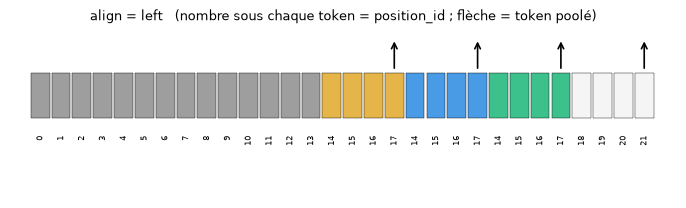

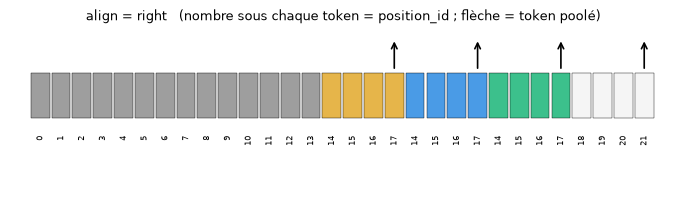

In [8]:
SEG_COLORS = {PREFIX_SEG: "#9e9e9e", ANS_SEG: "#f5f5f5", PAD_SEG: "#000000"}
CHOICE_COLORS = ["#e6b54a", "#4a9be6", "#3cc08c", "#d46ad4", "#e67a4a", "#7a7ae6"]
def seg_color(sg):
    return SEG_COLORS[sg] if sg <= 0 else CHOICE_COLORS[(sg - 1) % len(CHOICE_COLORS)]

def plot_layout(seq, title=""):
    n = len(seq["ids"])
    fig, ax = plt.subplots(figsize=(min(18, 0.22 * n + 2), 2.2))
    for j, (p, sg) in enumerate(zip(seq["pos"], seq["seg"])):
        ax.add_patch(plt.Rectangle((j, 0), 0.9, 0.9, color=seg_color(sg), ec="k", lw=0.3))
        ax.text(j + 0.45, -0.35, str(p), ha="center", va="top", fontsize=6, rotation=90)
    for j in seq["choice_last"] + [seq["answer_last"]]:
        ax.annotate("", xy=(j + 0.45, 0.95), xytext=(j + 0.45, 1.6), arrowprops=dict(arrowstyle="<-", lw=1.2))
    ax.set_xlim(-1, n + 1); ax.set_ylim(-1.6, 1.8); ax.axis("off")
    ax.set_title(title + "   (nombre sous chaque token = position_id ; flèche = token poolé)", fontsize=9)
    plt.show()

short = {"task": "intent", "question": "intent?", "state": "wake me 9am",
         "choices": ["alarm_set", "alarm_remove", "alarm_query"], "label": 0}
enc_short = encode_example(short)
plot_layout(build_sequence(enc_short, "left"), "align = left")
plot_layout(build_sequence(enc_short, "right"), "align = right")

## 6. Le masque d'attention 4D : les choix ne se voient jamais

Règles (en plus de la causalité par index dans la séquence plate) :

| requête ↓ / clé → | préfixe | même choix | autre choix | fin forcée | padding |
|---|---|---|---|---|---|
| préfixe | ✅ | – | – | – | ❌ |
| choix i | ✅ | ✅ | ❌ | – | ❌ |
| fin forcée | ✅ | ✅ | ✅ | ✅ | ❌ |
| padding | ❌ | ❌ | ❌ | ❌ | **lui-même seulement** |

La dernière ligne évite une ligne entièrement masquée (softmax de −∞ partout = `NaN`).

**Format attendu par transformers** : un masque 4D `(B, 1, L, L)` est transmis **tel quel** aux couches (pas de re-génération du masque causal). On le fournit sous forme **additive** (0 = autorisé, `finfo(dtype).min` = interdit), ce qui fonctionne avec `eager` comme avec `sdpa`. `flash_attention_2` ne supporte pas ces masques arbitraires.

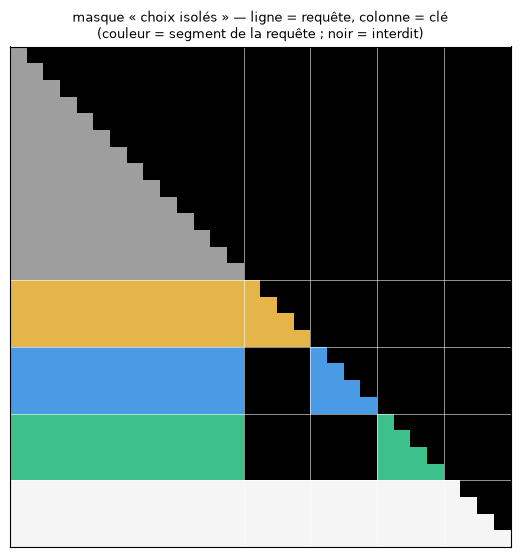

In [9]:
def build_allowed_mask(seg):
    """seg : (B, L) → allowed : (B, L, L) booléen, allowed[b, q, k] = la requête q peut regarder la clé k."""
    B, L = seg.shape
    idx = torch.arange(L, device=seg.device)
    causal = (idx[None, :] <= idx[:, None])[None]          # (1, L, L)  clé ≤ requête
    q, k = seg[:, :, None], seg[:, None, :]
    k_valid = k != PAD_SEG
    rule_prefix = (q == PREFIX_SEG) & (k == PREFIX_SEG)
    rule_choice = (q > 0) & ((k == PREFIX_SEG) | (k == q))
    rule_answer = (q == ANS_SEG) & k_valid
    allowed = causal & (rule_prefix | rule_choice | rule_answer)
    eye = torch.eye(L, dtype=torch.bool, device=seg.device)[None]
    allowed = allowed | (eye & (q == PAD_SEG))               # padding : se voit lui-même → pas de NaN
    return allowed

def additive_mask(allowed, dtype):
    m = torch.zeros(allowed.shape, dtype=dtype, device=allowed.device)
    m.masked_fill_(~allowed, torch.finfo(dtype).min)
    return m[:, None]                                        # (B, 1, L, L) : diffusé sur les têtes

def plot_mask(seq, title="masque"):
    seg = torch.tensor([seq["seg"]])
    A = build_allowed_mask(seg)[0].numpy()
    L = A.shape[0]
    img = np.zeros((L, L, 3))
    for qi in range(L):
        col = np.array(plt.matplotlib.colors.to_rgb(seg_color(seq["seg"][qi])))
        img[qi, A[qi]] = col
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.imshow(img, interpolation="nearest")
    # frontières de segments
    b = [j for j in range(1, L) if seq["seg"][j] != seq["seg"][j - 1]]
    for j in b:
        ax.axhline(j - 0.5, color="w", lw=0.4); ax.axvline(j - 0.5, color="w", lw=0.4)
    ax.set_title(title + " — ligne = requête, colonne = clé\n(couleur = segment de la requête ; noir = interdit)", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

plot_mask(build_sequence(enc_short), "masque « choix isolés »")

### 6.1 Collation d'un batch

Les exemples ont des longueurs et des nombres de choix différents : on **padde à droite** la séquence plate, et on padde la liste des choix jusqu'à `K = max k` du batch, avec un `choice_mask` booléen. C'est ici qu'apparaît la limite « 255 » de la vidéo : ce n'est qu'un plafond de `K`.

In [10]:
def collate(encs, align=None, pad_id=None):
    align = align or cfg.align
    pad_id = PAD_ID if pad_id is None else pad_id
    seqs = [build_sequence(e, align) for e in encs]
    B = len(seqs)
    L = max(len(s["ids"]) for s in seqs)
    K = max(len(s["choice_last"]) for s in seqs)
    input_ids = torch.full((B, L), pad_id, dtype=torch.long)
    position_ids = torch.zeros((B, L), dtype=torch.long)
    seg = torch.full((B, L), PAD_SEG, dtype=torch.long)
    choice_idx = torch.zeros((B, K), dtype=torch.long)
    choice_mask = torch.zeros((B, K), dtype=torch.bool)
    answer_idx = torch.zeros(B, dtype=torch.long)
    for i, s in enumerate(seqs):
        n, k = len(s["ids"]), len(s["choice_last"])
        input_ids[i, :n] = torch.tensor(s["ids"])
        position_ids[i, :n] = torch.tensor(s["pos"])
        seg[i, :n] = torch.tensor(s["seg"])
        choice_idx[i, :k] = torch.tensor(s["choice_last"])
        choice_mask[i, :k] = True
        answer_idx[i] = s["answer_last"]
    return {"input_ids": input_ids, "position_ids": position_ids, "seg": seg,
            "allowed": build_allowed_mask(seg), "choice_idx": choice_idx, "choice_mask": choice_mask,
            "answer_idx": answer_idx, "labels": torch.tensor([e["label"] for e in encs]),
            "task": torch.tensor([e["task"] for e in encs])}

def to_device(batch, device=None):
    device = device or DEVICE
    return {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}

b = collate([demo_enc, enc_short])
for k, v in b.items():
    print(f"{k:13s} {tuple(v.shape)} {v.dtype}")

input_ids     (2, 42) torch.int64
position_ids  (2, 42) torch.int64
seg           (2, 42) torch.int64
allowed       (2, 42, 42) torch.bool
choice_idx    (2, 4) torch.int64
choice_mask   (2, 4) torch.bool
answer_idx    (2,) torch.int64
labels        (2,) torch.int64
task          (2,) torch.int64


## 7. Pooling : un vecteur par choix + un vecteur réponse

Dans un décodeur causal, le **dernier token** d'un segment est le seul à avoir vu tout le segment. On récupère donc :

- `choices` : `h[b, choice_idx[b, i]]` → `(B, K, H)`, le dernier hidden de chaque choix (qui a vu préfixe + ce choix) ;
- `answer` : `h[b, answer_idx[b]]` → `(B, H)`, le dernier hidden de la fin forcée (qui a tout vu).

Comparaison avec le RAG : même logique de « last-token pooling » que les embedders dérivés de LLM, mais ici chaque vecteur est **conditionné par la question et l'état**. C'est ce qui en fait une représentation de *décision* et pas seulement de *contenu*.

In [11]:
def backbone_pool(backbone, batch, output_hidden_states=False):
    dt = next(backbone.parameters()).dtype
    out = backbone(input_ids=batch["input_ids"], position_ids=batch["position_ids"],
                   attention_mask=additive_mask(batch["allowed"], dt), use_cache=False,
                   output_hidden_states=output_hidden_states)
    h = out.last_hidden_state                                       # (B, L, H)
    ar = torch.arange(h.size(0), device=h.device)
    choices = h[ar[:, None], batch["choice_idx"]].float()            # (B, K, H)
    answer = h[ar, batch["answer_idx"]].float()                      # (B, H)
    return choices, answer, out

with torch.no_grad():
    ch, an, _ = backbone_pool(backbone, to_device(collate([demo_enc, enc_short])))
print("choices :", tuple(ch.shape), "| answer :", tuple(an.shape))
print("NaN ?", torch.isnan(ch).any().item(), torch.isnan(an).any().item())

choices : (2, 4, 1024) | answer : (2, 1024)
NaN ? False False


## 8. Tests sans entraînement

Avant d'entraîner quoi que ce soit, on vérifie (comme dans la vidéo) que la machinerie fait ce qu'on croit :

1. **Invariance** : on permute les choix, on remet les vecteurs dans l'ordre d'origine, l'écart doit être ≈ 0 (bruit numérique : ~1e-6 en float32, ~1e-2 en bf16).
2. **Contre-exemple** : avec des positions séquentielles et un masque causal standard, l'écart doit être **grand**. Si les deux tests donnent la même chose, le masque n'est pas pris en compte (mauvaise `attn_implementation`, version de transformers…).

In [12]:
def make_naive(batch):
    """Positions séquentielles + masque causal classique : ce qu'on obtient sans notre astuce."""
    b = dict(batch)
    valid = b["seg"] != PAD_SEG
    L = valid.size(1)
    b["position_ids"] = (valid.long().cumsum(-1) - 1).clamp(min=0)
    causal = torch.tril(torch.ones(L, L, dtype=torch.bool, device=valid.device))[None]
    eye = torch.eye(L, dtype=torch.bool, device=valid.device)[None]
    b["allowed"] = (causal & valid[:, None, :]) | (eye & ~valid[:, :, None])
    return b

def permute_example(ex, perm):
    ex2 = dict(ex)
    ex2["choices"] = [ex["choices"][p] for p in perm]
    if ex.get("label", -1) >= 0:
        ex2["label"] = perm.index(ex["label"])
    if "p_true" in ex:
        ex2["p_true"] = [ex["p_true"][p] for p in perm]
    return ex2

@torch.no_grad()
def invariance_gap(backbone, ex, n_perm=4, naive=False, seed=0):
    rng = random.Random(seed)
    k = len(ex["choices"])
    def reps(e):
        bt = to_device(collate([encode_example(e)]))
        if naive: bt = make_naive(bt)
        c, a, _ = backbone_pool(backbone, bt)
        return c[0], a[0]
    c0, a0 = reps(ex)
    gc, ga = 0.0, 0.0
    for _ in range(n_perm):
        perm = list(range(k)); rng.shuffle(perm)
        c1, a1 = reps(permute_example(ex, perm))
        back = torch.empty_like(c1); back[perm] = c1         # c1[j] = choix d'origine perm[j]
        gc = max(gc, (back - c0).abs().max().item() / (c0.abs().max().item() + 1e-8))
        ga = max(ga, (a1 - a0).abs().max().item() / (a0.abs().max().item() + 1e-8))
    return gc, ga

for naive in [False, True]:
    gc, ga = invariance_gap(backbone, demo_ex, naive=naive)
    print(f"{'NAÏF (causal standard)' if naive else 'NOTRE masque':24s} écart relatif choix={gc:.2e}  réponse={ga:.2e}")

NOTRE masque             écart relatif choix=1.38e-02  réponse=2.79e-02
NAÏF (causal standard)   écart relatif choix=3.00e-01  réponse=7.64e-02


## 9. Données

### 9.1 Schéma

Une ligne = un dict (ou une ligne JSONL), tout le reste du pipeline n'en demande pas plus :

```json
{"task": "trade_toy",
 "question": "Which action should the agent take now?",
 "state": "BTC-PERP 1h | ret_24h=+2.1% | rsi14=64 | funding=+0.012% | position=flat",
 "choices": ["open_long", "hold", "open_short"],
 "label": 0,
 "p_true": [0.61, 0.27, 0.12]}
```

`p_true` est optionnel : il n'existe que pour les données **procédurales** où l'on connaît la vraie distribution, ce qui permet de mesurer la calibration *contre la vérité* et pas seulement contre des labels bruités.

### 9.2 Trois sources de données

| Source | Exemple | Avantage | Risque |
|---|---|---|---|
| **Procédurale** | règles cachées, simulateur, jeu, environnement robot | volume infini, vérité connue, contrôle de la difficulté | le modèle apprend le générateur, pas le monde |
| **Réelle annotée** | intents (MASSIVE/SLURP, cf. l'exemple `alarm_set`), QCM, logs de décisions | réalisme | peu de mauvais choix explicites |
| **Augmentée** | réel + distracteurs générés | « hard negatives » | distracteurs trop faciles ou ambigus |

Augmentations réellement utiles ici :

- **nombre de choix variable** (2…6 à l'entraînement) : le modèle ne doit pas s'habituer à un K fixe ; on teste ensuite sur K plus grand ;
- **hard negatives** : distracteurs proches (même domaine, même préfixe d'intent, ±1 sur un nombre…) ;
- **distracteurs générés par un LLM**, avec vérification (un juge ou une règle) qu'ils sont bien faux ;
- *pas* besoin de permuter les choix : l'invariance est architecturale.

### 9.3 Générateurs procéduraux

1. `trade_toy` : un jouet de trading **stochastique**. Un signal caché combine rendement 24 h, RSI et funding ; la vraie politique est un softmax d'utilités ; le label est **tiré** de cette distribution. Le meilleur classifieur possible ne dépasse donc pas la « précision de Bayes », et la cible idéale est `p_true` : excellent pour apprendre à lire des courbes de calibration. **Ce n'est pas une stratégie de trading.**
2. `math_mc` : QCM arithmétique déterministe, avec des distracteurs « plausibles » (±1, ±10, chiffres inversés, mauvais opérateur) et un nombre de choix réglable.

In [13]:
def softmax_np(u):
    e = np.exp(u - u.max()); return e / e.sum()

def gen_trade(rng):
    ret = rng.gauss(0, 3.0)                                  # rendement 24 h en %
    rsi = min(95.0, max(5.0, 50 + 5 * ret + rng.gauss(0, 10)))
    funding = rng.gauss(0, 0.02)                             # en %
    pos = rng.choice(["flat", "long", "short"])
    signal = 0.5 * ret - 0.04 * (rsi - 50) - 20 * funding    # > 0 : haussier (règle cachée)
    if pos == "flat":
        util = {"open_long": signal, "open_short": -signal, "hold": 0.3}
    elif pos == "long":
        util = {"hold": 0.3 + 0.5 * signal, "close_position": -signal, "open_short": -signal - 0.5}
    else:
        util = {"hold": 0.3 - 0.5 * signal, "close_position": signal, "open_long": signal - 0.5}
    choices = list(util); rng.shuffle(choices)
    p = softmax_np(2.0 * np.array([util[c] for c in choices]))
    label = rng.choices(range(len(choices)), weights=p)[0]
    state = f"BTC-PERP 1h | ret_24h={ret:+.1f}% | rsi14={rsi:.0f} | funding={funding:+.3f}% | position={pos}"
    return {"task": "trade_toy", "question": "Which action should the agent take now?", "state": state,
            "choices": choices, "label": label, "p_true": p.tolist(),
            "meta": {"signal": signal, "pos": pos}}

def gen_math(rng, k_range=(2, 6)):
    a, b = rng.randint(2, 99), rng.randint(2, 99)
    op = rng.choice(["+", "-", "*"])
    ans = a + b if op == "+" else a - b if op == "-" else a * b
    pool = {ans + d for d in (1, -1, 2, -2, 10, -10, 11, -11, 100, -100)}
    pool |= {a + b, a - b, b - a, a * b}
    rev = int(str(abs(ans))[::-1]) * (1 if ans >= 0 else -1)
    pool.add(rev); pool.discard(ans)
    k = rng.randint(*k_range)
    distract = rng.sample(sorted(pool), min(k - 1, len(pool)))
    choices = [str(x) for x in [ans] + distract]; rng.shuffle(choices)
    return {"task": "math_mc", "question": f"What is {a} {op} {b}?", "state": "arithmetic, integers",
            "choices": choices, "label": choices.index(str(ans))}

rng = random.Random(0)
print(json.dumps(gen_trade(rng), indent=1))
print(json.dumps(gen_math(rng), indent=1))

{
 "task": "trade_toy",
 "question": "Which action should the agent take now?",
 "state": "BTC-PERP 1h | ret_24h=+2.8% | rsi14=50 | funding=-0.014% | position=short",
 "choices": [
  "hold",
  "open_long",
  "close_position"
 ],
 "label": 2,
 "p_true": [
  0.008599245809358128,
  0.26662872797931636,
  0.7247720262113255
 ],
 "meta": {
  "signal": 1.6780608853244263,
  "pos": "short"
 }
}
{
 "task": "math_mc",
 "question": "What is 40 - 63?",
 "state": "arithmetic, integers",
 "choices": [
  "-32",
  "77",
  "-33",
  "-13",
  "-25",
  "-23"
 ],
 "label": 5
}


### 9.4 Données réelles : intents MASSIVE (optionnel)

L'exemple « wake me up at nine am on friday → alarm_set » vient de ce type de corpus d'intents. Le chargeur ci-dessous construit des QCM avec **hard negatives** (intents du même scénario : `alarm_*`, `play_*`…). Il est désactivé par défaut (`cfg.use_intent`) pour que le notebook tourne hors-ligne ; le nom du dataset sur le Hub peut évoluer, d'où le code défensif.

In [14]:
def load_intent_examples(n, rng, k_range=(2, 6), hub_id="mteb/amazon_massive_intent", config="en"):
    from datasets import load_dataset
    ds = load_dataset(hub_id, config, split="train")
    cols = ds.column_names
    text_col = "text" if "text" in cols else "utt"
    if "label_text" in cols:
        labels = ds["label_text"]
    else:
        names = ds.features["label"].names
        labels = [names[i] for i in ds["label"]]
    all_intents = sorted(set(labels))
    by_scen = {}
    for it in all_intents:
        by_scen.setdefault(it.split("_")[0], []).append(it)
    idx = list(range(len(ds))); rng.shuffle(idx)
    out = []
    for i in idx[:n]:
        gold = labels[i]
        k = rng.randint(*k_range)
        hard = [x for x in by_scen[gold.split("_")[0]] if x != gold]
        rest = [x for x in all_intents if x != gold and x not in hard]
        neg = rng.sample(hard, min(len(hard), (k - 1 + 1) // 2))
        neg += rng.sample(rest, k - 1 - len(neg))
        choices = [gold] + neg; rng.shuffle(choices)
        out.append({"task": "intent", "question": "Which intent best matches this request?",
                    "state": ds[i][text_col], "choices": choices, "label": choices.index(gold)})
    return out

# Prompt type pour générer des distracteurs avec un LLM (à vérifier ensuite par une règle ou un juge) :
DISTRACTOR_PROMPT = """You create hard multiple-choice distractors.
State: {state}
Question: {question}
Correct answer: {gold}
Write {n} answers that are plausible but definitely WRONG for this state. One per line, no numbering."""

In [15]:
def build_splits(cfg):
    rng = random.Random(cfg.seed)
    def mix(n, k_range=(2, 6)):
        out = []
        for _ in range(n):
            out.append(gen_trade(rng) if rng.random() < 0.5 else gen_math(rng, k_range))
        return out
    train, val, test = mix(cfg.n_train), mix(cfg.n_val), mix(cfg.n_test)
    if cfg.use_intent:
        intents = load_intent_examples(cfg.n_train // 3 + cfg.n_val + cfg.n_test, rng)
        train += intents[: cfg.n_train // 3]
        val += intents[cfg.n_train // 3: cfg.n_train // 3 + cfg.n_val]
        test += intents[cfg.n_train // 3 + cfg.n_val:]
        rng.shuffle(train)
    # test de généralisation : plus de choix qu'à l'entraînement
    test_bigk = [gen_math(rng, k_range=(7, 10)) for _ in range(max(100, cfg.n_test // 4))]
    return train, val, test, test_bigk

train_ex, val_ex, test_ex, test_bigk_ex = build_splits(cfg)
t0 = time.time()
train_enc = [encode_example(e) for e in train_ex]
val_enc = [encode_example(e) for e in val_ex]
test_enc = [encode_example(e) for e in test_ex]
bigk_enc = [encode_example(e) for e in test_bigk_ex]
lens = [len(build_sequence(e)["ids"]) for e in train_enc[:500]]
print(f"{len(train_enc)} train / {len(val_enc)} val / {len(test_enc)} test / {len(bigk_enc)} test K∈[7,10]"
      f" — encodés en {time.time()-t0:.1f}s ; longueur plate moyenne {np.mean(lens):.0f}, max {max(lens)}")

40000 train / 2000 val / 2000 test / 500 test K∈[7,10] — encodés en 13.7s ; longueur plate moyenne 57, max 70


> **Pour vos données DeFi / trading réelles** : séparez train/val/test **dans le temps** (jamais de mélange aléatoire de dates), évitez toute fuite d'information future dans l'état, et validez par backtest hors échantillon avec frais et slippage. Un bon score de classification n'implique pas une stratégie rentable.

## 10. Têtes de décision

Les trois variantes de la vidéo, toutes **équivariantes** (permuter les choix permute les scores, rien d'autre) :

| Tête | Score du choix i | Paramètres | Les choix se comparent ? |
|---|---|---|---|
| `dot` | `cos(a, c_i) · τ` | 1 (τ) | ❌ — utile comme test zéro-entraînement |
| `bilinear` | `aᵀ W c_i`, avec `W = UᵀV` de rang d | 2·H·d | ❌ |
| `attn` (vidéo, « way three ») | self-attention (2 couches) sur `[task, c_1…c_k, a]` **sans encodage de position**, puis bilinéaire | ~ quelques M | ✅ |

Pourquoi « bilinéaire = deux projections + produit scalaire » : `(U a)·(V c) = aᵀ UᵀV c`. Une matrice pleine `H×H` coûterait 1 M de paramètres pour H = 1024 ; la factorisation de rang d est plus légère et régularise.

Deux ajouts par rapport au code de la vidéo :

- un **embedding de rôle** (choix / réponse) ajouté avant la self-attention, pour que la tête sache quel vecteur est la réponse. Il est identique pour tous les choix, donc l'équivariance est préservée ;
- le **task token** en tête de séquence, comme dans la vidéo : la tête sait si elle tranche une question d'intent, de maths ou de trading.

Les logits des choix de padding sont mis à `−∞`, donc leur probabilité softmax est exactement 0.

In [16]:
class DotHead(nn.Module):
    def __init__(self, hidden, **_):
        super().__init__()
        self.log_tau = nn.Parameter(torch.tensor(math.log(10.0)))
    def forward(self, choices, answer, choice_mask, task=None):
        s = torch.einsum("bd,bkd->bk", F.normalize(answer, dim=-1), F.normalize(choices, dim=-1))
        return (s * self.log_tau.exp()).masked_fill(~choice_mask, float("-inf"))

class BilinearHead(nn.Module):
    def __init__(self, hidden, d=512, **_):
        super().__init__()
        self.norm = nn.LayerNorm(hidden)
        self.U, self.V = nn.Linear(hidden, d), nn.Linear(hidden, d)
        self.d = d
    def forward(self, choices, answer, choice_mask, task=None):
        a, c = self.U(self.norm(answer)), self.V(self.norm(choices))
        s = torch.einsum("bd,bkd->bk", a, c) / math.sqrt(self.d)
        return s.masked_fill(~choice_mask, float("-inf"))

class Block(nn.Module):
    """Bloc transformer pré-norm, SANS encodage de position → équivariant par permutation."""
    def __init__(self, d, n_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, n_heads, dropout=dropout, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(d, mlp_ratio * d), nn.GELU(), nn.Linear(mlp_ratio * d, d))
    def forward(self, x, key_pad):
        h = self.n1(x)
        x = x + self.attn(h, h, h, key_padding_mask=key_pad, need_weights=False)[0]
        return x + self.mlp(self.n2(x))

class AttnHead(nn.Module):
    def __init__(self, hidden, d=512, n_layers=2, n_heads=8, n_tasks=len(TASKS), **_):
        super().__init__()
        self.inp = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, d))
        self.task_emb = nn.Embedding(n_tasks, d)
        self.role_emb = nn.Embedding(2, d)                     # 0 = choix, 1 = réponse
        self.blocks = nn.ModuleList([Block(d, n_heads) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d)
        self.answer_proj, self.choice_proj = nn.Linear(d, d), nn.Linear(d, d)
        self.d = d
    def forward(self, choices, answer, choice_mask, task):
        B, K, _ = choices.shape
        c = self.inp(choices) + self.role_emb.weight[0]
        a = self.inp(answer)[:, None] + self.role_emb.weight[1]
        t = self.task_emb(task)[:, None]
        x = torch.cat([t, c, a], dim=1)                          # (B, 1+K+1, d)
        ones = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
        key_pad = torch.cat([ones, ~choice_mask, ones], dim=1)   # True = ignorer
        for blk in self.blocks:
            x = blk(x, key_pad)
        x = self.norm(x)
        a = self.answer_proj(x[:, -1])
        c = self.choice_proj(x[:, 1:-1])
        s = torch.einsum("bd,bkd->bk", a, c) / math.sqrt(self.d)
        return s.masked_fill(~choice_mask, float("-inf"))

def make_head(cfg, hidden):
    H = {"dot": DotHead, "bilinear": BilinearHead, "attn": AttnHead}[cfg.head_type]
    return H(hidden, d=cfg.head_dim, n_layers=cfg.head_layers, n_heads=cfg.head_heads).to(DEVICE)

# Test d'équivariance des têtes sur des tenseurs aléatoires
Hd = backbone.config.hidden_size
for name in ["dot", "bilinear", "attn"]:
    head = {"dot": DotHead, "bilinear": BilinearHead, "attn": AttnHead}[name](Hd, d=64, n_heads=4).to(DEVICE).eval()
    ch_, an_ = torch.randn(2, 5, Hd, device=DEVICE), torch.randn(2, Hd, device=DEVICE)
    m_ = torch.tensor([[1, 1, 1, 1, 1], [1, 1, 1, 0, 0]], dtype=torch.bool, device=DEVICE)
    t_ = torch.tensor([0, 1], device=DEVICE)
    perm = torch.tensor([2, 0, 1, 3, 4], device=DEVICE)      # ne bouge pas le padding du 2e exemple
    with torch.no_grad():
        s1 = head(ch_, an_, m_, t_); s2 = head(ch_[:, perm], an_, m_[:, perm], t_)
    ok = torch.allclose(s1[:, perm][m_[:, perm]], s2[m_[:, perm]], atol=1e-5)
    print(f"{name:9s} équivariant : {ok} | P(padding) = {torch.softmax(s1, -1)[1, 3:].tolist()}")

dot       équivariant : True | P(padding) = [0.0, 0.0]
bilinear  équivariant : True | P(padding) = [0.0, 0.0]
attn      équivariant : True | P(padding) = [0.0, 0.0]


### 10.1 Le modèle complet

In [17]:
class DecisionModel(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone, self.head = backbone, head
    def forward(self, batch):
        choices, answer, _ = backbone_pool(self.backbone, batch)
        return self.head(choices, answer, batch["choice_mask"], batch["task"])   # (B, K) logits

def decision_loss(logits, labels, choice_mask, eps=0.0):
    """Entropie croisée sur les choix valides, avec label smoothing restreint aux choix valides."""
    logp = F.log_softmax(logits, dim=-1)
    nll = -logp.gather(1, labels[:, None]).squeeze(1)
    if eps > 0:
        smooth = -(logp.masked_fill(~choice_mask, 0.0).sum(-1) / choice_mask.sum(-1))
        nll = (1 - eps) * nll + eps * smooth
    return nll.mean()

# Test « zéro entraînement » : la tête dot sur le backbone brut (s'attendre à ~ hasard)
zs = DecisionModel(backbone, DotHead(Hd).to(DEVICE)).eval()
with torch.no_grad():
    bt = to_device(collate(val_enc[:16]))
    lg = zs(bt)
print("logits :", tuple(lg.shape), "| loss :", decision_loss(lg, bt["labels"], bt["choice_mask"]).item())
print("probas ex. 0 :", torch.softmax(lg[0], -1).cpu().numpy().round(3))

logits : (16, 6) | loss : 1.4225564002990723
probas ex. 0 : [0.212 0.203 0.189 0.179 0.217 0.   ]


## 11. Quelle couche ? Troncature et LoRA

### 11.1 Sonde par couche

Pour **mesurer** plutôt que supposer que la couche 20 est un bon point de sortie : on gèle le backbone, on extrait les vecteurs (choix, réponse) **à chaque couche** (`output_hidden_states=True`), et on entraîne une petite tête bilinéaire par couche. La courbe précision-vs-couche montre où l'information de décision est la plus accessible linéairement.

Note : dans HF, `hidden_states[0]` = sortie des embeddings, `hidden_states[l]` = sortie du bloc l, et le **dernier** inclut la norme finale.

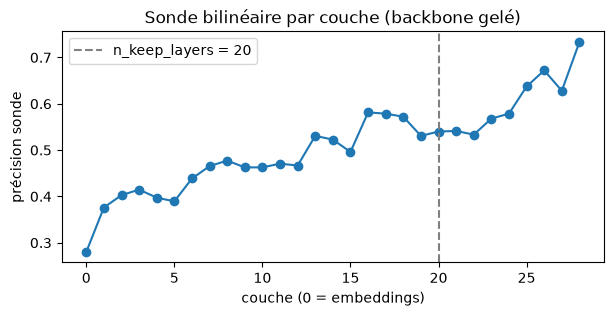

In [19]:
@torch.no_grad()
def collect_layer_feats(backbone, encs, bs=16):
    K = max(len(e["choices"]) for e in encs)
    C, A, M, Y = None, None, [], []
    for i in range(0, len(encs), bs):
        bt = to_device(collate(encs[i:i + bs]))
        _, _, out = backbone_pool(backbone, bt, output_hidden_states=True)
        hs = out.hidden_states
        ar = torch.arange(bt["input_ids"].size(0), device=DEVICE)
        kb = bt["choice_idx"].size(1)
        cs = torch.stack([h[ar[:, None], bt["choice_idx"]] for h in hs], 0).half().cpu()   # (nL, B, kb, H)
        cs = F.pad(cs, (0, 0, 0, K - kb))
        an = torch.stack([h[ar, bt["answer_idx"]] for h in hs], 0).half().cpu()           # (nL, B, H)
        C = cs if C is None else torch.cat([C, cs], 1)
        A = an if A is None else torch.cat([A, an], 1)
        M.append(F.pad(bt["choice_mask"].cpu(), (0, K - kb))); Y.append(bt["labels"].cpu())
    return C, A, torch.cat(M), torch.cat(Y)

def probe_layer(c, a, m, y, steps=150, d=128):
    n = len(y) // 2
    head = BilinearHead(c.size(-1), d=d).to(DEVICE)
    opt = torch.optim.Adam(head.parameters(), lr=1e-3)
    c, a, m, y = c.float().to(DEVICE), a.float().to(DEVICE), m.to(DEVICE), y.to(DEVICE)
    for _ in range(steps):
        loss = decision_loss(head(c[:n], a[:n], m[:n]), y[:n], m[:n])
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        return (head(c[n:], a[n:], m[n:]).argmax(-1) == y[n:]).float().mean().item()

N_PROBE = 200 if cfg.tiny_debug else 1500
C, A, M, Y = collect_layer_feats(backbone, train_enc[:N_PROBE])
accs = [probe_layer(C[l], A[l], M, Y) for l in range(C.size(0))]
plt.figure(figsize=(7, 3)); plt.plot(range(len(accs)), accs, "o-")
plt.axvline(cfg.n_keep_layers, ls="--", c="gray", label=f"n_keep_layers = {cfg.n_keep_layers}")
plt.xlabel("couche (0 = embeddings)"); plt.ylabel("précision sonde"); plt.legend(); plt.title("Sonde bilinéaire par couche (backbone gelé)")
plt.show()
del C, A

### 11.2 Troncature

On coupe les couches au-delà de `n_keep_layers` : moins de calcul (≈ −28 % ici) et, selon l'intuition de la vidéo, des représentations moins spécialisées « token suivant ». La norme finale de Qwen est conservée (une simple RMSNorm), la tête a de toute façon sa propre normalisation.

### 11.3 LoRA

Entraîner seulement la tête laisse le backbone figé : les représentations ne s'adaptent pas à la tâche. LoRA ajoute à chaque projection ciblée une mise à jour de rang r, `W' = W + (α/r)·BA`, avec `B` initialisée à 0 (le modèle de départ est inchangé au pas 0). On l'applique aux **12 dernières couches gardées** (8…19), sur les 7 projections de chaque bloc (q, k, v, o, gate, up, down). Plus lent par pas, mais apprend beaucoup mieux (+10 points dans la vidéo).

```mermaid
flowchart LR
  E["embeddings<br/>gelés"] --> L0["couches 0…7<br/>gelées"] --> L8["couches 8…19<br/>gelées + LoRA r=16"] --> X["couches 20…27<br/>SUPPRIMÉES"]
  L8 --> P["pooling"] --> H["tête attn<br/>entraînée"]
```

In [22]:
def truncate_layers(backbone, n):
    backbone.layers = backbone.layers[:n]
    backbone.config.num_hidden_layers = n
    if getattr(backbone.config, "layer_types", None):
        backbone.config.layer_types = backbone.config.layer_types[:n]
    return backbone

def apply_lora(backbone, cfg):
    for p in backbone.parameters():
        p.requires_grad_(False)
    if not cfg.use_lora:
        return backbone
    from peft import LoraConfig, get_peft_model
    n = len(backbone.layers)
    lcfg = LoraConfig(r=cfg.lora_r, lora_alpha=cfg.lora_alpha, lora_dropout=cfg.lora_dropout, bias="none",
                      target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
                      layers_to_transform=list(range(n - cfg.lora_last_n, n)), layers_pattern="layers")
    pm = get_peft_model(backbone, lcfg)
    pm.print_trainable_parameters()
    return pm

backbone = truncate_layers(backbone, cfg.n_keep_layers)
if cfg.grad_ckpt:
    backbone.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
backbone = apply_lora(backbone, cfg)
model = DecisionModel(backbone, make_head(cfg, Hd))
n_head = sum(p.numel() for p in model.head.parameters())
n_train_bb = sum(p.numel() for p in model.backbone.parameters() if p.requires_grad)
print(f"couches gardées : {cfg.n_keep_layers} | tête : {n_head/1e6:.2f} M | LoRA : {n_train_bb/1e6:.2f} M paramètres entraînables")
print("invariance après troncature + LoRA :", invariance_gap(model.backbone, demo_ex))

trainable params: 4,325,376 || all params: 474,527,744 || trainable%: 0.9115
couches gardées : 20 | tête : 7.36 M | LoRA : 4.33 M paramètres entraînables
invariance après troncature + LoRA : (0.011627906974941411, 0.01481481481262003)


## 12. Entraînement

- **Perte** : entropie croisée sur les choix valides (règle de score *propre* : elle est minimisée en espérance par les vraies probabilités, ce qui pousse vers la calibration). Label smoothing optionnel, limité aux choix valides.
- **Optimiseur** : AdamW avec **deux learning rates** — tête (3e-4, initialisée à zéro de connaissance) et LoRA (1e-4, perturbation d'un modèle pré-entraîné).
- **Schedule** : warmup linéaire puis cosinus.
- **Précision** : backbone en bf16, adaptateurs LoRA et tête en float32 (peft gère la conversion), pas besoin d'autocast.
- **Budget indicatif** : la vidéo annonce ~24 h sur une A100 (≈ 36 $) pour l'entraînement complet. Commencez par quelques milliers de pas et regardez les courbes de validation.

Astuce efficacité (non implémentée pour rester lisible) : regrouper les exemples de longueurs proches dans un même batch (bucketing) réduit fortement le padding.

step   300/2500 | loss 0.6912 | val acc 0.682 nll 0.6612 | 60s
step   600/2500 | loss 0.6251 | val acc 0.752 nll 0.5676 | 121s
step   900/2500 | loss 0.5726 | val acc 0.765 nll 0.5385 | 180s
step  1200/2500 | loss 0.5474 | val acc 0.782 nll 0.4946 | 240s
step  1500/2500 | loss 0.5043 | val acc 0.786 nll 0.4881 | 300s
step  1800/2500 | loss 0.4559 | val acc 0.795 nll 0.4652 | 358s
step  2100/2500 | loss 0.4720 | val acc 0.800 nll 0.4562 | 416s
step  2400/2500 | loss 0.4213 | val acc 0.804 nll 0.4487 | 476s
step  2500/2500 | loss 0.4832 | val acc 0.805 nll 0.4477 | 496s


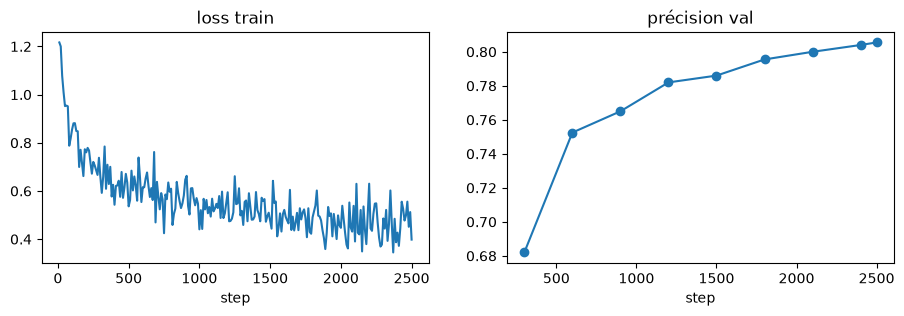

In [23]:
from torch.utils.data import DataLoader
from transformers import get_cosine_schedule_with_warmup

@torch.no_grad()
def predict(model, encs, bs=32):
    model.eval()
    out = []
    for i in range(0, len(encs), bs):
        bt = to_device(collate(encs[i:i + bs]))
        lg = model(bt).float().cpu(); m = bt["choice_mask"].cpu()
        out += [lg[j, : int(m[j].sum())] for j in range(lg.size(0))]
    return out                                                   # liste de tenseurs (k_i,)

def quick_eval(model, encs):
    lgs = predict(model, encs)
    y = [e["label"] for e in encs]
    acc = np.mean([int(l.argmax()) == t for l, t in zip(lgs, y)])
    nll = np.mean([-torch.log_softmax(l, -1)[t].item() for l, t in zip(lgs, y)])
    return acc, nll

def train(model, train_enc, val_enc, cfg):
    head_p = [p for p in model.head.parameters() if p.requires_grad]
    lora_p = [p for p in model.backbone.parameters() if p.requires_grad]
    groups = [{"params": head_p, "lr": cfg.lr_head}] + ([{"params": lora_p, "lr": cfg.lr_lora}] if lora_p else [])
    opt = torch.optim.AdamW(groups, weight_decay=cfg.weight_decay)
    dl = DataLoader(train_enc, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate, num_workers=0)
    total = cfg.epochs * len(dl)
    sched = get_cosine_schedule_with_warmup(opt, int(cfg.warmup_ratio * total), total)
    hist = {"step": [], "loss": [], "val_step": [], "val_acc": [], "val_nll": []}
    step, t0, run = 0, time.time(), []
    for ep in range(cfg.epochs):
        for bt in dl:
            model.train()
            bt = to_device(bt)
            loss = decision_loss(model(bt), bt["labels"], bt["choice_mask"], cfg.label_smoothing)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head_p + lora_p, cfg.grad_clip)
            opt.step(); sched.step(); step += 1
            run.append(loss.item())
            if step % 10 == 0:
                hist["step"].append(step); hist["loss"].append(np.mean(run[-10:]))
            if step % cfg.eval_every == 0 or step == total:
                acc, nll = quick_eval(model, val_enc)
                hist["val_step"].append(step); hist["val_acc"].append(acc); hist["val_nll"].append(nll)
                print(f"step {step:5d}/{total} | loss {np.mean(run[-50:]):.4f} | val acc {acc:.3f} nll {nll:.4f} | {time.time()-t0:.0f}s")
    return hist

hist = train(model, train_enc, val_enc, cfg)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(hist["step"], hist["loss"]); ax[0].set_title("loss train"); ax[0].set_xlabel("step")
ax[1].plot(hist["val_step"], hist["val_acc"], "o-"); ax[1].set_title("précision val"); ax[1].set_xlabel("step")
plt.show()

## 13. Validation

Un modèle de décision se juge sur **cinq axes**, pas seulement la précision :

| Axe | Métrique | Question |
|---|---|---|
| Justesse | précision, NLL | choisit-il le bon choix ? |
| Calibration | **ECE**, Brier, diagramme de fiabilité | quand il dit 80 %, a-t-il raison 80 % du temps ? |
| Vérité terrain (procédural) | KL(p_true ‖ p_modèle), précision de Bayes | approche-t-il la vraie distribution ? |
| Invariance / généralisation | écart sous permutation, précision à K plus grand qu'à l'entraînement | la structure tient-elle ? |
| Coût | latence d'une décision, débit | est-ce vraiment un Système 1 ? |

**ECE** (Expected Calibration Error) : on range les prédictions par confiance (probabilité du choix retenu) dans 15 intervalles, et on fait la moyenne pondérée de |précision − confiance| par intervalle.

**Brier multi-classe** : Σ_i (p_i − y_i)², une autre règle de score propre, bornée.

**Température** : on cherche T > 0 minimisant la NLL sur la validation et on divise les logits par T. Ne change jamais l'argmax (donc la précision), corrige la sur- ou sous-confiance globale. À appliquer sur un ensemble distinct du test.

── test brut (T=1.00)
  math_mc    n 1034 | acc 0.9188 | nll 0.1790 | brier 0.1099 | ece 0.0219
  trade_toy  n 966 | acc 0.6977 | nll 0.7065 | brier 0.4104 | ece 0.0283 | kl_true 0.0848 | acc_bayes 0.7274 | acc_expected 0.6917
── test après température (ajustée sur val) (T=1.21)
  math_mc    n 1034 | acc 0.9188 | nll 0.1752 | brier 0.1089 | ece 0.0133
  trade_toy  n 966 | acc 0.6977 | nll 0.7037 | brier 0.4094 | ece 0.0314 | kl_true 0.0806 | acc_bayes 0.7274 | acc_expected 0.6917


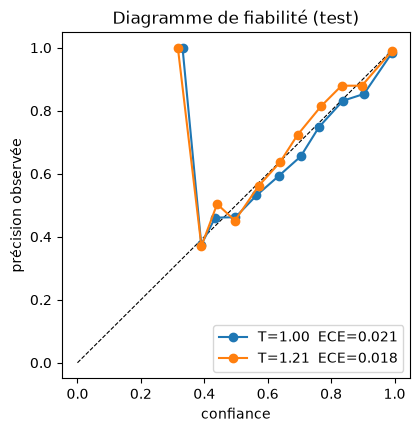

In [24]:
def pad_logits(lgs, fill=-1e4):
    # valeur FINIE pour le padding : avec -inf, d(x/T)/dT = inf·0 = NaN dans LBFGS
    K = max(len(l) for l in lgs)
    out = torch.full((len(lgs), K), fill)
    for i, l in enumerate(lgs): out[i, : len(l)] = l
    return out

def fit_temperature(lgs, labels):
    X, y = pad_logits(lgs), torch.tensor(labels)
    logT = torch.zeros(1, requires_grad=True)
    opt = torch.optim.LBFGS([logT], lr=0.1, max_iter=200)
    def closure():
        opt.zero_grad(); loss = F.cross_entropy(X / logT.exp(), y); loss.backward(); return loss
    opt.step(closure)
    return logT.exp().item()

def calib_metrics(lgs, exs, T=1.0, n_bins=15):
    y = np.array([e["label"] for e in exs])
    P = [torch.softmax(l / T, -1).numpy() for l in lgs]
    pred = np.array([p.argmax() for p in P]); conf = np.array([p.max() for p in P])
    correct = (pred == y).astype(float)
    nll = np.mean([-np.log(max(p[t], 1e-12)) for p, t in zip(P, y)])
    brier = np.mean([((p - np.eye(len(p))[t]) ** 2).sum() for p, t in zip(P, y)])
    bins = np.minimum((conf * n_bins).astype(int), n_bins - 1)
    ece, rel = 0.0, []
    for b in range(n_bins):
        m = bins == b
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
            rel.append((conf[m].mean(), correct[m].mean(), m.sum()))
    res = {"n": len(y), "acc": float(correct.mean()), "nll": float(nll), "brier": float(brier), "ece": float(ece)}
    if all("p_true" in e for e in exs):
        PT = [np.array(e["p_true"]) for e in exs]
        res["kl_true"] = float(np.mean([(pt * (np.log(pt + 1e-12) - np.log(p + 1e-12))).sum() for pt, p in zip(PT, P)]))
        res["acc_bayes"] = float(np.mean([pt.max() for pt in PT]))                 # meilleur possible en espérance
        res["acc_expected"] = float(np.mean([pt[p.argmax()] for pt, p in zip(PT, P)]))
    return res, rel

def report(lgs, exs, T=1.0, title=""):
    print(f"── {title} (T={T:.2f})")
    for task in sorted(set(e["task"] for e in exs)):
        idx = [i for i, e in enumerate(exs) if e["task"] == task]
        r, _ = calib_metrics([lgs[i] for i in idx], [exs[i] for i in idx], T)
        print(f"  {task:10s} " + " | ".join(f"{k} {v:.4f}" if isinstance(v, float) else f"{k} {v}" for k, v in r.items()))

def reliability_plot(lgs, exs, Ts=(1.0,), title=""):
    plt.figure(figsize=(4.5, 4.5)); plt.plot([0, 1], [0, 1], "k--", lw=0.8)
    for T in Ts:
        r, rel = calib_metrics(lgs, exs, T)
        xs, ys, ns = zip(*rel)
        plt.plot(xs, ys, "o-", label=f"T={T:.2f}  ECE={r['ece']:.3f}")
    plt.xlabel("confiance"); plt.ylabel("précision observée"); plt.title(title); plt.legend(); plt.show()

val_lgs, test_lgs = predict(model, val_enc), predict(model, test_enc)
T_star = fit_temperature(val_lgs, [e["label"] for e in val_ex])
report(test_lgs, test_ex, 1.0, "test brut")
report(test_lgs, test_ex, T_star, "test après température (ajustée sur val)")
reliability_plot(test_lgs, test_ex, (1.0, T_star), "Diagramme de fiabilité (test)")

In [25]:
# Invariance du modèle complet + généralisation à plus de choix + latence
@torch.no_grad()
def permutation_consistency(model, exs, n=100, seed=0):
    rng = random.Random(seed); gaps = []
    for ex in exs[:n]:
        k = len(ex["choices"]); perm = list(range(k)); rng.shuffle(perm)
        p0 = torch.softmax(predict(model, [encode_example(ex)])[0], -1)
        p1 = torch.softmax(predict(model, [encode_example(permute_example(ex, perm))])[0], -1)
        back = torch.empty_like(p1); back[perm] = p1
        gaps.append((back - p0).abs().max().item())
    return max(gaps), float(np.mean(gaps))

print("écart de probabilité sous permutation (max, moyen) :", permutation_consistency(model, test_ex, n=50))
bigk_lgs = predict(model, bigk_enc)
report(bigk_lgs, test_bigk_ex, T_star, "math_mc avec K ∈ [7, 10] (jamais vu à l'entraînement : K ≤ 6)")

@torch.no_grad()
def latency(model, enc, n=30, bs=1):
    bt = to_device(collate([enc] * bs)); model.eval()
    for _ in range(3): model(bt)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n): model(bt)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n

for bs in [1, 16]:
    dt = latency(model, test_enc[0], bs=bs)
    print(f"batch {bs:3d} : {dt*1000:.1f} ms / passe → {bs/dt:.0f} décisions/s")

écart de probabilité sous permutation (max, moyen) : (0.07390308380126953, 0.001951259401152397)
── math_mc avec K ∈ [7, 10] (jamais vu à l'entraînement : K ≤ 6) (T=1.21)
  math_mc    n 500 | acc 0.8000 | nll 0.4128 | brier 0.2474 | ece 0.0310
batch   1 : 34.0 ms / passe → 29 décisions/s
batch  16 : 33.8 ms / passe → 473 décisions/s


## 14. Calibration et RL : ce qu'on sait, ce qu'on propose

**Ce qu'on sait.** La méthode exacte « Reinforcement Learning for Calibrated Decisions » de TypeSafe AI n'est, à ma connaissance, pas publiée ; tout ce qui suit est une proposition, pas une reconstruction.

**Ce que garantit l'entropie croisée.** C'est une règle de score propre : à capacité infinie, son optimum est la vraie probabilité conditionnelle. En pratique, les réseaux sur-entraînés deviennent sur-confiants, d'où la température.

**Pourquoi le RL « naïf » ne calibre pas.** Avec une récompense de type gain (succès, PnL), le gradient de politique pousse vers l'action d'espérance maximale : la politique optimale est **déterministe**. Les probabilités deviennent des préférences, plus des probabilités. Si l'on veut à la fois une bonne politique et des probabilités honnêtes, il faut l'un de ces garde-fous :

1. garder un terme **CE / règle propre** dans la perte (ce que fait le code ci-dessous, coefficient `ce_coef`) ;
2. séparer **politique** (quelle action) et **croyance** (probabilité que chaque choix soit le bon), et récompenser la croyance par une règle de score propre (log-score ou Brier) — c'est l'esprit des travaux récents qui ajoutent un terme de Brier à la récompense pour entraîner des LLM à exprimer une confiance calibrée ;
3. recalibrer après coup (température, isotonic) sur un ensemble frais.

**Quand le RL est vraiment utile** : quand le label n'existe pas mais qu'un **résultat** est observable après la décision (trading : PnL réalisé ; robot : succès de la tâche ; ARC-AGI-3 : progression dans le jeu). C'est un **bandit contextuel** : un état, une action, une récompense.

Le code ci-dessous fait un REINFORCE avec baseline sur le jouet de trading : l'exposition résultante de l'action est multipliée par un rendement futur simulé `r ~ N(0.8·signal, 1)`, moins des frais de transaction. On compare la récompense espérée de la politique (argmax) avant et après.

In [26]:
EXPO = {"open_long": 1, "open_short": -1, "close_position": 0}
POS = {"flat": 0, "long": 1, "short": -1}
FEE = 0.1

def trade_reward(ex, action, rng=None):
    pos = POS[ex["meta"]["pos"]]
    expo = pos if ex["choices"][action] == "hold" else EXPO[ex["choices"][action]]
    mu = 0.8 * ex["meta"]["signal"]
    r = mu if rng is None else rng.gauss(mu, 1.0)            # rng=None → récompense espérée
    return expo * r - FEE * abs(expo - pos)

def expected_policy_reward(model, exs):
    lgs = predict(model, [encode_example(e) for e in exs])
    return float(np.mean([trade_reward(e, int(l.argmax())) for e, l in zip(exs, lgs)]))

def rl_finetune(model, n_steps=200, bs=16, lr=2e-5, ent_coef=0.01, ce_coef=0.5, seed=1):
    rng = random.Random(seed)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr)
    for step in range(1, n_steps + 1):
        model.train()
        exs = [gen_trade(rng) for _ in range(bs)]
        bt = to_device(collate([encode_example(e) for e in exs]))
        logits = model(bt)
        dist = torch.distributions.Categorical(logits=logits.masked_fill(~bt["choice_mask"], -1e9))
        a = dist.sample()
        R = torch.tensor([trade_reward(e, int(ai), rng) for e, ai in zip(exs, a.tolist())], device=DEVICE)
        adv = (R - R.mean()) / (R.std() + 1e-6)
        loss = -(adv * dist.log_prob(a)).mean() - ent_coef * dist.entropy().mean()
        loss = loss + ce_coef * decision_loss(logits, bt["labels"], bt["choice_mask"])   # ancrage « règle propre »
        opt.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        if step % 50 == 0:
            print(f"rl step {step} | reward moyen batch {R.mean().item():+.3f}")

eval_trades = [gen_trade(random.Random(123 + i)) for i in range(300)]
oracle = np.mean([max(trade_reward(e, i) for i in range(len(e["choices"]))) for e in eval_trades])
print(f"récompense espérée : avant RL {expected_policy_reward(model, eval_trades):+.3f} | oracle {oracle:+.3f}")
model_rl = copy.deepcopy(model)                               # on garde le modèle supervisé intact
rl_finetune(model_rl, n_steps=50 if cfg.tiny_debug else 500)
print(f"récompense espérée : après RL {expected_policy_reward(model_rl, eval_trades):+.3f}")
report(predict(model_rl, [encode_example(e) for e in eval_trades]), eval_trades, 1.0, "calibration après RL (trade_toy)")

récompense espérée : avant RL +0.369 | oracle +0.597
rl step 50 | reward moyen batch +0.125
rl step 100 | reward moyen batch +0.643
rl step 150 | reward moyen batch +1.007
rl step 200 | reward moyen batch +0.651
rl step 250 | reward moyen batch +0.834
rl step 300 | reward moyen batch +0.468
rl step 350 | reward moyen batch +0.541
rl step 400 | reward moyen batch +0.199
rl step 450 | reward moyen batch +0.424
rl step 500 | reward moyen batch +0.075
récompense espérée : après RL +0.433
── calibration après RL (trade_toy) (T=1.00)
  trade_toy  n 300 | acc 0.6500 | nll 0.7558 | brier 0.4561 | ece 0.1109 | kl_true 0.0922 | acc_bayes 0.7225 | acc_expected 0.6791


## 15. Sauvegarde, inférence, intégration

On ne sauvegarde que ce qui a été entraîné : les adaptateurs LoRA (quelques Mo), la tête, la config et la température. Le backbone se recharge depuis le Hub puis est tronqué à l'identique.

In [27]:
def save_decision_model(model, path, T=1.0):
    os.makedirs(path, exist_ok=True)
    torch.save(model.head.state_dict(), f"{path}/head.pt")
    if cfg.use_lora:
        model.backbone.save_pretrained(f"{path}/lora")
    json.dump({**asdict(cfg), "temperature": T, "tasks": TASKS}, open(f"{path}/cfg.json", "w"), indent=1)

def load_decision_model(path):
    meta = json.load(open(f"{path}/cfg.json"))
    c = CFG(**{k: v for k, v in meta.items() if k in CFG.__dataclass_fields__})
    bb = truncate_layers(load_backbone(c, tok), c.n_keep_layers)
    if c.use_lora:
        from peft import PeftModel
        bb = PeftModel.from_pretrained(bb, f"{path}/lora")
    head = make_head(c, bb.config.hidden_size)
    head.load_state_dict(torch.load(f"{path}/head.pt", map_location=DEVICE))
    return DecisionModel(bb, head).eval(), meta["temperature"]
# (en mode tiny, le backbone est aléatoire : le rechargement ne retrouverait pas les mêmes poids de base)

save_decision_model(model, "decision_model_ckpt", T_star)

@torch.no_grad()
def decide(model, question, state, choices, task, T=1.0):
    ex = {"task": task, "question": question, "state": state, "choices": choices, "label": 0}
    lg = model.eval()(to_device(collate([encode_example(ex)])))[0, : len(choices)].float()
    p = torch.softmax(lg / T, -1).tolist()
    return sorted(zip(choices, p), key=lambda x: -x[1])

decide(model, "Which action should the agent take now?",
       "BTC-PERP 1h | ret_24h=+4.2% | rsi14=58 | funding=-0.010% | position=flat",
       ["open_long", "hold", "open_short"], "trade_toy", T_star)

[('open_long', 0.9190611243247986),
 ('hold', 0.077605701982975),
 ('open_short', 0.003333116415888071)]

### 15.1 Vers mes autres projets

**Module Système 1 dans une architecture IERM / robotique.** Le module répond à « parmi ces options, laquelle, et avec quelle confiance ? ». Le Système 2 (planificateur, LLM plus gros, recherche) propose ou filtre les options et n'est appelé que si la **confiance est basse** ou l'**entropie** élevée : la calibration n'est donc pas un luxe, c'est le signal de routage.

**ARC-AGI-3** (jeux interactifs à actions discrètes) : état = sérialisation de la grille + historique court ; choix = actions disponibles (ou macro-actions proposées par un planificateur) ; entraînement initial procédural, puis bandit contextuel / RL sur la progression observée. L'invariance à l'ordre des actions et le K variable sont exactement ce qu'il faut.

**Décisions de trading rapides** : état = features déjà calculées (texte compact, comme le jouet) plutôt que séries brutes ; choix = actions et tailles discrétisées ; labels = issues réelles futures (avec séparation temporelle stricte) puis RL sur PnL simulé avec frais. Gardez le Système 1 comme filtre / proposeur sous contrôle de règles de risque déterministes.

**Si besoin absolument un backbone hybride (Qwen3.5).** L'astuce masque + positions ne s'applique pas, mais une alternative préserve l'invariance : encoder le préfixe une fois, **dupliquer l'état récurrent** (de taille fixe pour Gated DeltaNet, ce qui rend la copie peu coûteuse) puis encoder chaque choix dans sa propre branche ; la comparaison se fait uniquement dans la tête. Plus complexe à implémenter avec HF (manipulation des caches), à réserver à une V2.

### 15.2 Pistes d'amélioration à tester

| Piste | Pourquoi |
|---|---|
| `align="right"` vs `"left"` | distance relative identique entre chaque choix poolé et la réponse |
| `n_keep_layers` selon la sonde (§11.1) | mesurer plutôt que deviner |
| Bucketing par longueur | 2–3× moins de padding |
| Préfixe partagé par plusieurs questions | un seul état, plusieurs décisions en une passe (même astuce de masque) |
| Option « aucune / abstention » explicite | utile en robotique et en trading |
| Distillation depuis un Système 2 | labels = décisions d'un gros modèle raisonnant, puis RL |

## A. Annexe : passer au code de production avec Claude Code

Proposition de découpage du notebook en paquet testable :

```
decision_s1/
  encoding.py      # templates, encode_example, build_sequence
  masking.py       # build_allowed_mask, additive_mask, make_naive
  collate.py       # collate, to_device
  heads.py         # DotHead, BilinearHead, AttnHead, make_head
  model.py         # load_backbone, truncate_layers, apply_lora, DecisionModel, backbone_pool
  data/            # générateurs procéduraux, chargeurs, schéma JSONL
  train.py         # boucle, optim, scheduler, logging
  evaluate.py      # calib_metrics, fit_temperature, reliability, permutation, latency
  rl.py            # bandit contextuel
tests/
  test_mask.py         # règles du tableau §6, absence de lignes vides
  test_invariance.py   # mini-Qwen3 aléatoire : écart ≈ 0 avec notre masque, grand en naïf
  test_heads.py        # équivariance, P(padding) = 0
  test_collate.py      # index poolés, positions, K variable
```

Consignes utiles à donner à l'agent (dans un `CLAUDE.md`) :

- les tests d'invariance tournent sur le **mini-Qwen3 aléatoire** (CPU, quelques secondes) et doivent passer avant tout entraînement ;
- `attn_implementation` ∈ {`sdpa`, `eager`} uniquement, jamais flash-attention 2 avec ce masque ;
- toute modification de `build_sequence` ou `build_allowed_mask` doit garder les tests verts ;
- configuration par dataclass / YAML, une seule source de vérité ; logs vers TensorBoard ou W&B ;
- épingler les versions de `torch`, `transformers`, `peft` (l'API de masques de transformers évolue d'une version à l'autre).

### Checklist des pièges

| Piège | Symptôme | Parade |
|---|---|---|
| Masque 4D ignoré | invariance « NOTRE masque » ≈ « NAÏF » au §8 | `sdpa`/`eager`, masque additif `(B,1,L,L)` |
| Ligne de masque entièrement interdite | `NaN` dans les hidden states | le padding se voit lui-même |
| Nouveaux tokens spéciaux + LoRA | tokens jamais appris | marqueurs texte existants |
| `Linear(d, 255)` en sortie | dépendance à l'ordre | score par paire (einsum `bd,bkd->bk`) |
| Encodage de position dans la tête | dépendance à l'ordre | aucun, seulement embeddings de rôle et de tâche |
| Split aléatoire sur séries temporelles | métriques irréalistes | split temporel |
| Label smoothing avec logits `−∞` | perte infinie | smoothing restreint aux choix valides |
| Température ajustée sur le test | calibration optimiste | l'ajuster sur la validation |